In [11]:
%load_ext autoreload
%autoreload 2

from folde.util import load_checkpointed_model_eval, convert_compaign_result_collection_to_df, DMS_SHORTNAMES

results = load_checkpointed_model_eval(
    'notebooks/jacob/model_evals/',
    '250720-embedding-param-scan',
    []
)
mutant_df, round_metrics_df = convert_compaign_result_collection_to_df(results)
round_metrics_df['dms_shortname'] = round_metrics_df.dms_id.apply(lambda x: DMS_SHORTNAMES[x])

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Loading results for DMSs: {'BLAT_ECOLX_Firnberg_2014', 'OXDA_RHOTO_Vanella_2023_activity', 'SHOC2_HUMAN_Kwon_2022', 'HEM3_HUMAN_Loggerenberg_2023', 'HSP82_YEAST_Flynn_2019', 'HXK4_HUMAN_Gersing_2022_activity', 'PPM1D_HUMAN_Miller_2022', 'ANCSZ_Hobbs_2022', 'CBS_HUMAN_Sun_2020'}


/var/folders/p6/jn7zk09154v2f60d993vb2sm0000gn/T/ipykernel_20433/248044945.py:72: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')


Text(0.5, 0, 'Embedding Model Size')

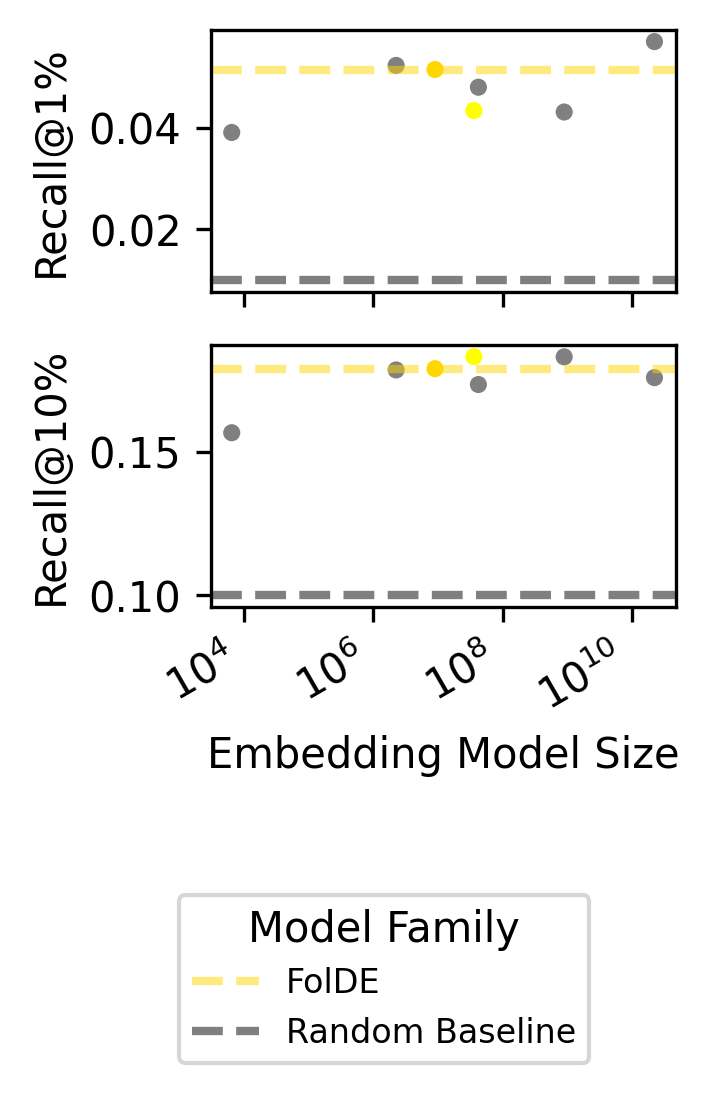

In [48]:
import re
import seaborn as sns
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(2, 2.5), sharex=True, dpi=300)

ROUND = 3

model_name_list = [
    ('FolDE-base', 'base'),
    ('FolDE-8m', 'ESM2-8m'),
    # ('FolDE-35m', 'ESM2-35m'),
    ('FolDE-150m', 'ESM2-150m'),
    ('FolDE-650m', 'ESM2-650m'),
    ('FolDE-3b', 'ESM2-3b'),
    ('FolDE-15b', 'ESM2-15b'),
    ('FolDE-300m', 'ESMC-300m'),
    ('FolDE-600m', 'ESMC-600m'),
]

def name_to_size(name):
    if not re.match(r'.*-\d+[bm]', name):
        return 0.0
    sizestr = name.split('-')[1]
    size = float(sizestr[:-1])
    if sizestr.endswith('b'):
        size *= 1e9
    elif sizestr.endswith('m'):
        size *= 1e6
    return size

model_name_map = {k: v for k, v in model_name_list}
initial_metrics_df = round_metrics_df[round_metrics_df.round_num == ROUND].copy()
initial_metrics_df['model_name'] = initial_metrics_df.config_name.apply(lambda x: model_name_map[x])
initial_metrics_df['Model Family'] = initial_metrics_df.model_name.apply(lambda x: x.split('-')[0])
initial_metrics_df['Model Size'] = initial_metrics_df.model_name.apply(name_to_size)


for ii, (ax, metric) in enumerate(zip([ax1, ax2], ['held_out_1pct_recall', 'held_out_10pct_recall'])):
    grouped_df = initial_metrics_df.groupby(['model_name', 'round_num', 'Model Family', 'Model Size'])[metric].mean().reset_index()
    def get_color(model_name):
        if model_name.startswith('ESM2'):
            return 'grey'
        elif model_name == 'ESMC-300m':
            return 'gold'
        else:
            return 'yellow'
    sns.scatterplot(
        data=grouped_df[
            (grouped_df.model_name != 'base')
        ],
        hue='model_name',
        x='Model Size',
        y=metric,
        ax=ax,
        s=20,
        palette={c[1]: get_color(c[1]) for c in model_name_list},
        legend=False,
    )
    ax.set_xscale('log')
    # sns.barplot(
    #     data=initial_metrics_df[
    #         (initial_metrics_df.model_name != 'base')
    #     ],
    #     x='model_name',
    #     y=metric,
    #     order=[v for k, v in model_name_list[1:]],
    #     # hue='Model Family',
    #     palette={c[1]: get_color(c[1]) for c in model_name_list},
    #     ax=ax,
    # )
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')

    ax.axhline(
        y=initial_metrics_df[initial_metrics_df.model_name == 'ESMC-300m'][metric].mean(),
        color='gold',
        linestyle='--',
        linewidth=2,
        alpha=0.5,
        label='FolDE'
    )
    ax.axhline(
        y=0.01 if metric == 'held_out_1pct_recall' else 0.1,
        color='black',
        linestyle='--',
        linewidth=2,
        alpha=0.5,
        label='Random Baseline'
    )

    if metric == 'held_out_1pct_recall':
        ax.set_ylabel('Recall@1%')
    elif metric == 'held_out_10pct_recall':
        ax.set_ylabel('Recall@10%')
    ax.set_xticks([1e7, 1e8, 1e9, 1e10])
    # ax.set_xticklabels(['10m', '1b'])
    
# ax1.get_legend().remove()
ax2.legend(
    title='Model Family',
    loc='lower right',
    bbox_to_anchor=(0.85, -1.8),
    fontsize=8
)

ax2.set_xlabel('Embedding Model Size')


